In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_pickle("submission_data.pkl")

In [4]:
df.head(5)

,Sno,Lecture,StudentNo,Total_Characters,Total_Words,Submission_Time,Submission_Delay,x_01,x_02,x_03,...,x_91,x_92,x_93,x_94,x_95,x_96,x_97,x_98,x_99,x_100
0,1,1,86,195,29,2025-08-01 12:27:27,-41253,-0.077114,0.253333,0.011405,...,0.337617,0.168170,0.017231,0.159088,0.464630,0.317253,0.096538,-0.298382,0.120905,-0.077520
1,2,1,157,1113,200,2025-08-01 12:54:15,-39645,-0.067545,0.227569,0.008495,...,0.307100,0.149335,0.018137,0.146451,0.420410,0.289732,0.086327,-0.268150,0.107681,-0.068773
2,3,1,96,1789,333,2025-08-01 14:48:09,-32811,-0.063024,0.214906,0.007124,...,0.290288,0.140544,0.018353,0.140202,0.396785,0.271830,0.081143,-0.253906,0.101067,-0.065998
3,4,1,107,3102,533,2025-08-01 15:28:08,-30412,-0.048755,0.171059,0.006272,...,0.229764,0.111833,0.014593,0.110382,0.314830,0.216020,0.063341,-0.200269,0.078878,-0.052138
4,5,1,113,2939,460,2025-08-01 16:00:43,-28457,-0.067291,0.227849,0.009686,...,0.307524,0.149782,0.019012,0.146942,0.422824,0.289825,0.085539,-0.269843,0.108719,-0.069168


In [5]:
df['target'] = (df['Submission_Delay'] > 0).astype(int)
df = df.drop(columns=['Submission_Delay'])

/var/folders/dw/dcpyjh2s1ml5h145lgj8b9hc0000gn/T/ipykernel_71319/826368721.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = (df['Submission_Delay'] > 0).astype(int)


In [6]:
print(df['target'].value_counts())

target
0    1398
1     220
Name: count, dtype: int64


In [7]:
df.sample(5)

,Sno,Lecture,StudentNo,Total_Characters,Total_Words,Submission_Time,x_01,x_02,x_03,x_04,...,x_92,x_93,x_94,x_95,x_96,x_97,x_98,x_99,x_100,target
20,21,1,134,723,121,2025-08-01 19:30:40,-0.081609,0.272573,0.010251,-0.019455,...,0.179733,0.021901,0.177027,0.506103,0.347910,0.103652,-0.325125,0.127907,-0.083156,0
1064,1065,7,91,452,77,2025-08-29 23:48:50,-0.115919,0.221141,0.149932,0.162082,...,0.203760,0.003434,0.214045,0.637908,0.427463,0.132396,-0.491809,0.271895,-0.237582,0
372,373,3,16,2310,358,2025-08-08 22:02:32,-0.161208,0.173830,0.164145,0.109390,...,0.323592,-0.045685,0.038725,0.617666,0.322980,0.133608,-0.257471,0.088287,-0.104032,0
177,178,2,156,1083,198,2025-08-06 19:40:00,-0.223493,0.343265,-0.039668,0.027196,...,0.187574,-0.026081,0.190899,0.726677,0.386007,0.056274,-0.373947,0.131488,-0.198671,0
253,254,2,69,1314,223,2025-08-06 23:00:00,-0.211882,0.321016,-0.040494,0.027066,...,0.178242,-0.027560,0.179907,0.678620,0.361633,0.059551,-0.348047,0.125019,-0.185933,0


In [8]:
df.dtypes

Sno                   int64
Lecture               int64
StudentNo             int64
Total_Characters      int64
Total_Words           int64
                     ...   
x_97                float64
x_98                float64
x_99                float64
x_100               float64
target                int64
Length: 107, dtype: object

In [9]:
df.size

173126

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
from sklearn.preprocessing import StandardScaler

feature_cols = []
for col in df.columns:
    if col.startswith('x_'):
        feature_cols.append(col)
        
X = df[feature_cols]
y = df['target']

# FIX: Changed 'scalar' to 'scaler' to match the next line
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [12]:
print(df[feature_cols[:3]].describe())
# close to zero , acceptable enough

               x_01          x_02          x_03
count  1.618000e+03  1.618000e+03  1.618000e+03
mean  -7.026381e-17 -3.074042e-16  1.580936e-16
std    1.000309e+00  1.000309e+00  1.000309e+00
min   -3.411581e+00 -2.714986e+00 -1.840512e+00
25%   -5.358593e-01 -6.146997e-01 -8.063971e-01
50%   -9.496264e-02  1.422680e-01 -1.063301e-01
75%    9.356005e-01  6.353760e-01  7.930033e-01
max    1.905096e+00  2.941827e+00  2.308307e+00


In [13]:
df.sample(5)

,Sno,Lecture,StudentNo,Total_Characters,Total_Words,Submission_Time,x_01,x_02,x_03,x_04,...,x_92,x_93,x_94,x_95,x_96,x_97,x_98,x_99,x_100,target
1330,1331,9,13,1538,236,2025-09-07 23:34:35,-0.081318,0.622224,-0.847613,-0.068544,...,-0.058627,1.268492,-0.761427,-0.283496,-1.374815,1.789411,-0.109252,-0.074679,1.338669,0
1258,1259,9,166,1311,203,2025-09-07 14:48:06,-0.243553,0.886010,-0.826385,-0.049992,...,0.088958,1.344824,-0.773562,0.013719,-1.138822,2.059866,-0.363000,0.058100,1.337462,0
1200,1201,8,22,1341,208,2025-09-03 23:44:30,-2.474891,0.681754,0.743534,-0.126536,...,1.010596,0.636403,-1.845634,1.249532,-0.878854,0.953448,-2.197213,-0.741794,1.187822,0
137,138,1,67,1247,219,2025-08-02 02:49:39,1.442950,-0.229139,-1.026890,-0.619872,...,-0.343807,0.671862,1.129477,-1.133608,-0.755084,-0.681177,0.515549,-0.669360,0.659729,1
366,367,3,34,1593,294,2025-08-08 21:43:09,-0.067664,-0.721809,1.633779,1.204811,...,2.545625,-1.082721,-0.092237,1.302746,0.211671,0.290939,0.332454,-0.890615,-0.051516,0


In [14]:
# Correlation btw features and target var
correlations = df[feature_cols].corrwith(df['target'])
# finding out top 15 features
top_15_features = correlations.abs().nlargest(15).index.tolist()
top_15_features

['x_04',
 'x_05',
 'x_54',
 'x_74',
 'x_84',
 'x_19',
 'x_52',
 'x_25',
 'x_100',
 'x_38',
 'x_02',
 'x_86',
 'x_48',
 'x_53',
 'x_61']

In [15]:
plt.figure(figsize=(12, 10))
top_15_corr_matrix = df[top_15_features].corr()

<Figure size 1200x1000 with 0 Axes>

<Axes: >

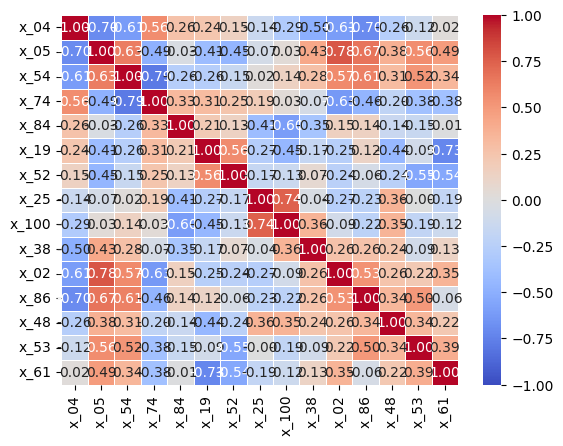

In [16]:
# HeatMAP
import seaborn as sns
sns.heatmap(
    top_15_corr_matrix,
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",          
    linewidths=0.5,      
    vmin=-1, vmax=1      
)

### Correlation Explanation


## Dimensionality Reduction

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


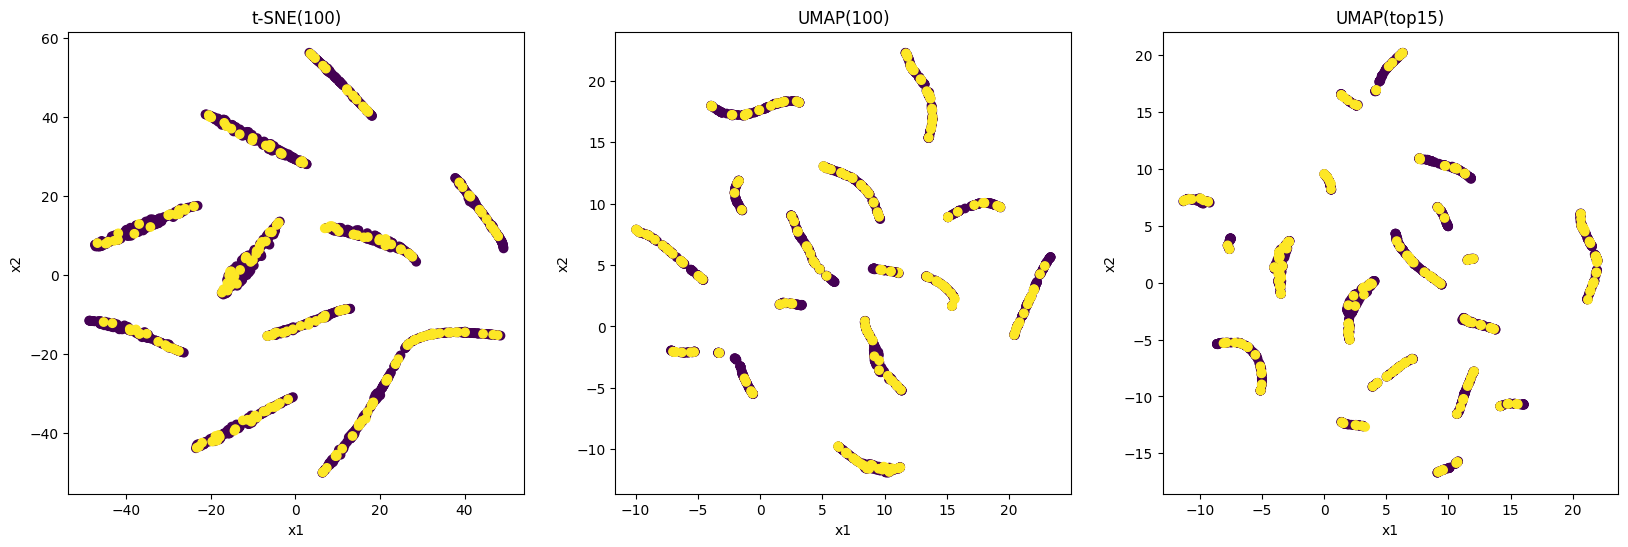

In [21]:
from sklearn.manifold import TSNE
import umap

X_all = df[feature_cols]
X_top_15 = df[top_15_features]

colors = df['target']

#TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne_all = tsne.fit_transform(X_all)

# UMAP on all features
umap_model_all = umap.UMAP(random_state=42)
X_umap_all = umap_model_all.fit_transform(X_all)

# UMAP on 15 top features
umap_top15 = umap.UMAP(random_state=42)
X_umap_top15 = umap_top15.fit_transform(X_top_15)

# plotting graph
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scatter1 = axes[0].scatter(X_tsne_all[:, 0], X_tsne_all[:, 1], c=colors)
axes[0].set_title('t-SNE(100)')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

scatter2 = axes[1].scatter(X_umap_all[:, 0], X_umap_all[:, 1], c=colors)
axes[1].set_title('UMAP(100)')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('x1')

scatter3 = axes[2].scatter(X_umap_top15[:, 0], X_umap_top15[:, 1], c=colors)
axes[2].set_title('UMAP(top15)')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')


plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X = df[top_15_features]
y = df['target']

X_train, X_test , y_train,y_test = train_test_split(X,y,test_size=0.2 ,random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
lr = LogisticRegression(random_state=42)
lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print('Logistic Regression')
print(classification_report(y_test,lr_pred,zero_division=0))
print('ROC_AUC', roc_auc_score(y_test,lr_prob))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       284
           1       0.00      0.00      0.00        40

    accuracy                           0.88       324
   macro avg       0.44      0.50      0.47       324
weighted avg       0.77      0.88      0.82       324

ROC_AUC 0.511443661971831


In [34]:
from sklearn.svm import SVC
svc = SVC(probability=True,random_state=42)
svc.fit(X_train,y_train)

svc_pred = svc.predict(X_test)
svc_prob = svc.predict_proba(X_test)[:,1]

print('SVC')
print(classification_report(y_test,svc_pred,zero_division=0))
print('ROC_AUC',roc_auc_score(y_test,svc_prob))

SVC
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       284
           1       0.00      0.00      0.00        40

    accuracy                           0.88       324
   macro avg       0.44      0.50      0.47       324
weighted avg       0.77      0.88      0.82       324

ROC_AUC 0.3525528169014084


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print('Random Forest Model')
print(classification_report(y_test,rf_pred,zero_division=0))
print('ROC_AUC',roc_auc_score(y_test,rf_prob))

Random Forest Model
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       284
           1       0.00      0.00      0.00        40

    accuracy                           0.84       324
   macro avg       0.44      0.48      0.46       324
weighted avg       0.76      0.84      0.80       324

ROC_AUC 0.5098151408450705


In [38]:
# ALL models in one go for 100 features 
X_all = df[feature_cols]
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.20, random_state=42)

# LR
lr_100 = LogisticRegression(random_state=42).fit(X_train_all, y_train_all)
lr_rep = classification_report(y_test_all, lr_100.predict(X_test_all), output_dict=True ,zero_division=0)
lr_auc = roc_auc_score(y_test_all, lr_100.predict_proba(X_test_all)[:, 1])

# SVC
svc_100 = SVC(probability=True, random_state=42).fit(X_train_all, y_train_all)
svc_rep = classification_report(y_test_all, svc_100.predict(X_test_all), output_dict=True,zero_division=0)
svc_auc = roc_auc_score(y_test_all, svc_100.predict_proba(X_test_all)[:, 1])

# RF
rf_100 = RandomForestClassifier(random_state=42).fit(X_train_all, y_train_all)
rf_rep = classification_report(y_test_all, rf_100.predict(X_test_all), output_dict=True,zero_division=0)
rf_auc = roc_auc_score(y_test_all, rf_100.predict_proba(X_test_all)[:, 1])

print(f"Logistic Regression -> Acc: {lr_rep['accuracy']:.4f} | F1 (Class 1): {lr_rep['1']['f1-score']:.4f} | AUC: {lr_auc:.4f}")
print(f"SVC                 -> Acc: {svc_rep['accuracy']:.4f} | F1 (Class 1): {svc_rep['1']['f1-score']:.4f} | AUC: {svc_auc:.4f}")
print(f"Random Forest       -> Acc: {rf_rep['accuracy']:.4f} | F1 (Class 1): {rf_rep['1']['f1-score']:.4f} | AUC: {rf_auc:.4f}")

Logistic Regression -> Acc: 0.8765 | F1 (Class 1): 0.0000 | AUC: 0.5145
SVC                 -> Acc: 0.8765 | F1 (Class 1): 0.0000 | AUC: 0.4304
Random Forest       -> Acc: 0.8364 | F1 (Class 1): 0.0000 | AUC: 0.4892
